# Cell segmentation and morphology analysis

This notebook is a locally runnable example of the segmentation workflow implemented in `scripts/segment_cells.py`. That script runs at scale on [Modal](https://modal.com) with GPU-backed containers and reads/writes data to S3. Here, the same core steps (preprocessing, segmentation, property extraction) run on a small subset of images using the best available local device (GPU if present, otherwise CPU).

The goal is to segment individual cells from DIC microscopy images, extract morphological measurements (area, perimeter, axis lengths, etc.) in physical units (microns), and compare cell shape across two strains (WT and DEA2) grown with and without a single 3 mm bead.

In [ ]:
from pathlib import Path

import arcadia_pycolor as apc
import pandas as pd
from arcadia_microscopy_tools import MicroscopyImage
from tqdm.notebook import tqdm

# Configures matplotlib defaults (colors, spine style, fonts) to match Arcadia's publication style.
# Falls back to default matplotlib fonts if the Arcadia brand fonts aren't installed locally.
font_dirpath = Path("~/Library/Fonts")
apc.mpl.setup(font_dirpath=str(font_dirpath))

## Define sample metadata

Each row corresponds to a single microscopy image (ND2 file) with its associated experimental conditions. This experimental subset is a 2×2 design: two strains (WT, DEA2) crossed with two bead conditions (no bead, single 3 mm bead).

Note: the ND2 filenames reference the FITC channel, but these images were actually acquired in DIC and saved under the wrong channel label.

In [2]:
DATA_DIR = Path("../data/microscopy").resolve()

keys = ["strain", "bead_size_mm", "nd2_path"]
records = [
    ("WT", "none", DATA_DIR / "WellB10_PointB10_0004_ChannelFITC BP_Seq0094.nd2"),
    ("WT", 3, DATA_DIR / "WellB06_PointB06_0002_ChannelFITC BP_Seq0128.nd2"),
    ("DEA2", "none", DATA_DIR / "WellF10_PointF10_0007_ChannelFITC BP_Seq0277.nd2"),
    ("DEA2", 3, DATA_DIR / "WellF06_PointF06_0003_ChannelFITC BP_Seq0309.nd2"),
]

# Create a DataFrame from the records
sample_metadata = pd.DataFrame(records, columns=keys)
sample_metadata

,strain,bead_size_mm,nd2_path
0,WT,none,/Users/ryanlane/Repositories/2026-bead-growth/...
1,WT,3,/Users/ryanlane/Repositories/2026-bead-growth/...
2,DEA2,none,/Users/ryanlane/Repositories/2026-bead-growth/...
3,DEA2,3,/Users/ryanlane/Repositories/2026-bead-growth/...


## Segment cells and extract morphological properties

For each image, this cell:
1. Loads the ND2 file and extracts the pixel size from the instrument metadata.
2. Preprocesses the image by rescaling intensities by percentile.
3. Runs a segmentation model to produce a labeled cell mask.
4. Converts region properties (area, perimeter, axis lengths, eccentricity, etc.) from pixels to microns using the known pixel size.

The per-cell measurements from all images are concatenated into a single DataFrame (`cell_measurements`).

In [3]:
from arcadia_microscopy_tools import ImageOperation, Pipeline
from arcadia_microscopy_tools.channels import DIC
from arcadia_microscopy_tools.masks import SegmentationMask
from arcadia_microscopy_tools.model import SegmentationModel
from arcadia_microscopy_tools.operations import rescale_by_percentile

# DIC images are 16-bit integers; percentile rescaling maps to a [0, 1] float range.
# Without preserve_dtype=False, the floats would be cast back to int and collapse to 0 or 1.
pipeline = Pipeline([ImageOperation(rescale_by_percentile)], preserve_dtype=False)
model = SegmentationModel()

preprocessed_images = []
segmentation_masks = []
per_image_dfs = []
for _i, row in tqdm(sample_metadata.iterrows(), total=len(sample_metadata)):
    strain = row["strain"]
    bead_size_mm = row["bead_size_mm"]
    nd2_path = row["nd2_path"]

    # Load the ND2 file, overriding the mislabeled channel parsed from the metadata with the
    # the known DIC channel.
    image = MicroscopyImage.from_nd2_path(nd2_path, channels=[DIC])

    # XY pixel pitch in microns, embedded in the ND2 file's instrument metadata.
    # Needed to convert all downstream pixel measurements to physical units.
    pixel_size_um = image.metadata.instrument.channel_metadata_list[0].resolution.xy_step_um

    # Get the DIC channel as a numpy array
    intensities = image.get_intensities_from_channel(DIC)
    preprocessed = pipeline(intensities)
    preprocessed_images.append(preprocessed)

    # segment() runs a deep-learning model that assigns each pixel a cell label (0 = background).
    # SegmentationMask wraps the label array to provide regionprops and boundary tracing.
    mask = model.segment(preprocessed)
    mask = SegmentationMask(mask)
    segmentation_masks.append(mask)

    # Runs scikit-image regionprops on each labeled cell, then scales pixel measurements
    # (area, perimeter, axis lengths, etc.) by pixel_size_um. Returns a dict of lists.
    cell_props = mask.convert_properties_to_microns(pixel_size_um)
    cell_props["strain"] = strain
    cell_props["bead_size_mm"] = bead_size_mm

    # Convert the dict of lists returned by convert_properties_to_microns() to a DataFrame
    image_cell_df = pd.DataFrame.from_dict(cell_props)
    per_image_dfs.append(image_cell_df)

# Concatenate per-image dataframes into a single DataFrame
cell_measurements = pd.concat(per_image_dfs)

# Show a random sample of 3 cells from each strain x bead condition
cell_measurements.groupby(["strain", "bead_size_mm"]).sample(3)

  0%|          | 0/4 [00:00<?, ?it/s]

,label,volume_um3,area_um2,area_convex_um2,perimeter_um,eccentricity,circularity,solidity,axis_major_length_um,axis_minor_length_um,orientation,centroid_y,centroid_x,strain,bead_size_mm
27,28,250.042395,75.442656,79.113125,42.841437,0.970041,0.516534,0.953605,20.075692,4.877219,-0.082805,892.591180,908.952048,DEA2,3
10,11,246.539718,75.917969,80.222188,45.231922,0.972266,0.466299,0.946346,20.494428,4.793208,-0.354157,286.957217,515.857739,DEA2,3
20,21,231.410690,64.932969,67.520781,36.111627,0.946459,0.625721,0.961674,16.186394,5.225373,-1.541405,600.670598,946.520537,DEA2,3
27,28,169.968040,44.072031,45.128281,25.751056,0.808482,0.835185,0.976594,9.786226,5.759393,-1.364442,983.569802,316.871180,DEA2,none
19,20,194.037671,54.660938,55.981250,31.479967,0.917297,0.693136,0.976415,13.270668,5.284420,-0.548353,860.199034,950.205797,DEA2,none
4,5,216.829009,49.221250,50.541563,26.804914,0.719357,0.860862,0.973877,9.503115,6.601253,-1.463225,246.120172,207.446352,DEA2,none
19,20,105.944668,38.157031,40.058281,27.668392,0.938428,0.626349,0.952538,11.923835,4.119384,-1.169604,299.634602,758.815917,WT,3
67,68,86.369815,32.664531,33.958438,24.799153,0.929823,0.667441,0.961897,10.679482,3.930127,0.457413,967.529507,689.495554,WT,3
47,48,82.272806,30.155938,31.291406,23.167388,0.909433,0.706039,0.963713,9.685623,4.027774,-1.352424,763.702277,981.186515,WT,3
39,40,121.524083,37.417656,38.553125,24.933773,0.872709,0.756328,0.970548,9.911329,4.839115,1.086792,580.277347,270.078335,WT,none


## Compare cell elongation across conditions

Box plot of major axis length grouped by strain and bead condition. Major axis length serves as a proxy for cell elongation. Individual cell measurements are overlaid as a strip plot.

The box plot below shows that the major axis length—a proxy for cell elongation—is greater for both the wild-type (WT) and mutant (dea2Δ) strains in the presence of a 3 mm bead compared to "no bead" condition. This trend holds true for both strains. Note that these data are from a single field of view per condition, which limits the generalizability of the findings. To increase generalizability, high-throughput imaging was done for the full experiment, which is why cell segmentation was scaled to run with Modal.

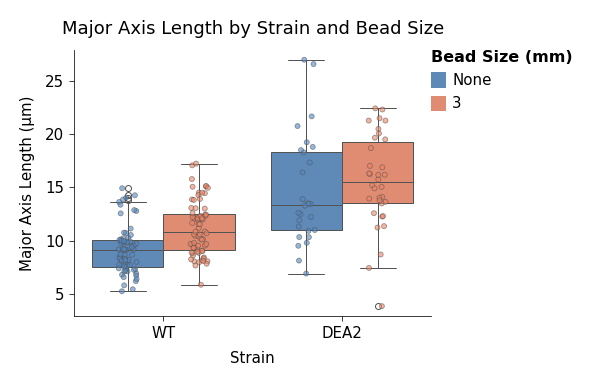

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()

# Use Arcadia's primary color palette for the two strains
palette = apc.palettes.primary.colors[:2]

# Plot the box plot
sns.boxplot(
    data=cell_measurements,
    x="strain",
    y="axis_major_length_um",
    hue="bead_size_mm",
    palette=palette,
    ax=ax,
)

# Overlay individual data points on the boxes to visualize sample size and spread
sns.stripplot(
    data=cell_measurements,
    x="strain",
    y="axis_major_length_um",
    hue="bead_size_mm",
    dodge=True,
    ax=ax,
    marker="o",
    alpha=0.6,
    palette=palette,
    linewidth=0.8,
    legend=False,
)

_ = ax.set_title("Major Axis Length by Strain and Bead Size")
_ = ax.set_ylabel("Major Axis Length (μm)")
_ = ax.set_xlabel("Strain")
_ = ax.legend(title="Bead Size (mm)")
_ = apc.mpl.style_plot(ax)
_ = sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

## Visual QC: segmentation overlays

Preprocessed grayscale images with segmentation outlines drawn in yellow. Each panel shows the strain, bead condition, and number of cells detected. Use this to visually verify that the segmentation is capturing real cells and not artifacts.

Note: cells on the edge of the field of view are not segmented since the measurements of these cells are note reliable.

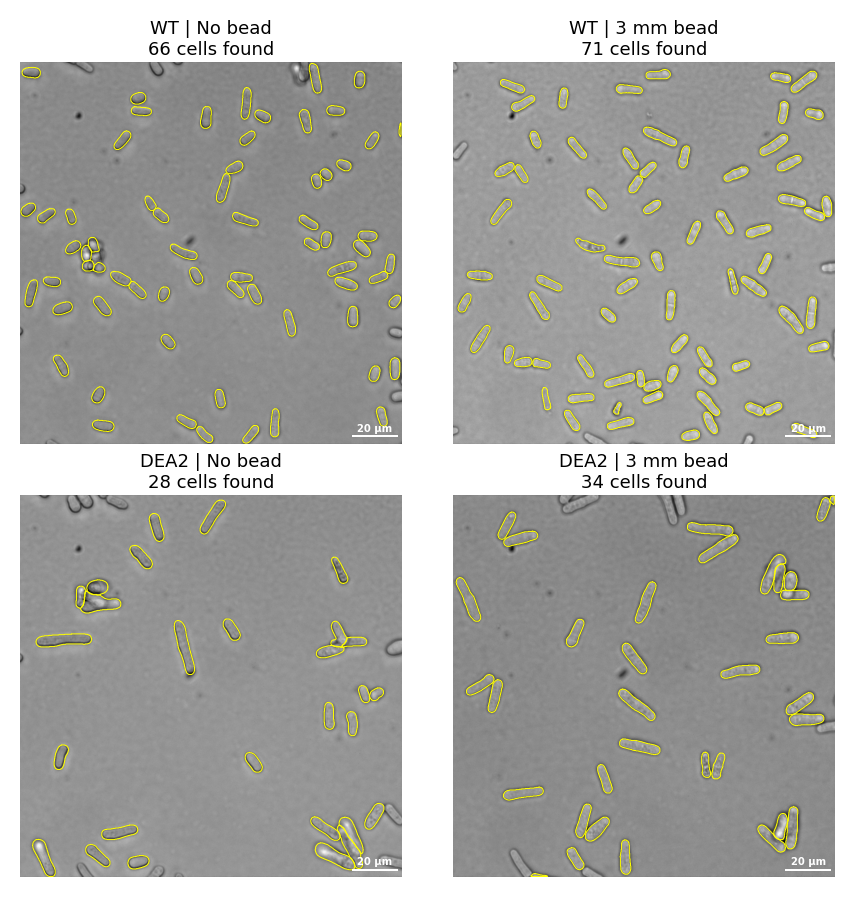

In [8]:
# Create figure
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 12),
    layout="constrained",
)

# Iterate over the sample metadata to plot each image
for i, row in sample_metadata.iterrows():
    strain = row["strain"]
    bead_size_mm = row["bead_size_mm"]
    ax = axes.flatten()[i]

    preprocessed = preprocessed_images[i]
    ax.imshow(preprocessed, cmap="gray")

    # Each outline is an (N, 2) array of boundary pixel coordinates for one segmented cell.
    # Coordinates are in row-col (yx) order, so we index [:, 1] for x and [:, 0] for y.
    mask = segmentation_masks[i]
    for coords_yx in mask.cell_outlines:
        ax.plot(coords_yx[:, 1], coords_yx[:, 0], "#ffff00", lw=1)

    # Add a 20 µm scale bar to each subplot
    scalebar_um = 20
    scalebar_pixels = int(scalebar_um / pixel_size_um)
    # Position: 10 pixels from bottom right
    x0 = preprocessed.shape[1] - (scalebar_pixels + 10)
    y0 = preprocessed.shape[0] - 20
    ax.plot(
        [x0, x0 + scalebar_pixels],
        [y0, y0],
        color="white",
        linewidth=2,
        solid_capstyle="butt",
    )
    ax.text(
        x0 + scalebar_pixels // 2,
        y0 - 10,
        f"{scalebar_um} µm",
        color="white",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

    bead_str = f"{bead_size_mm} mm bead" if bead_size_mm != "none" else "No bead"
    title = f"{strain} | {bead_str}\n{mask.num_cells} cells found"
    ax.set_title(title, y=0.98)
    ax.axis("off")